# Benchmark validation: Exponential quintessence

This notebook validates the $(w_p, f_p)$ dark energy density parameterization against an exponential quintessence potential $V(\phi) = V_0 \, e^{\lambda \phi / M_{\rm pl}}$ with $\lambda = 0.7$.

We compare how well the $(w_p, f_p)$ and CPL $(w_0, w_a)$ parameterizations reproduce the exact expansion history $H(z)$ of the quintessence model, by scanning their respective parameter spaces and computing the maximum relative error $E_H$ (Eq. 14 of the paper).

**Output**: Figure 1 of the paper.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from tqdm import trange
from skimage import measure
from classy_fDE import Class
from scipy.optimize import minimize, brentq, curve_fit
from scipy.integrate import cumtrapz
from scipy.interpolate import interp1d, CubicSpline
from matplotlib.gridspec import GridSpec
from matplotlib import cm
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
import scienceplots
plt.style.use('mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

## Quintessence model setup

Solve the scalar field dynamics for an exponential potential using `class_ede` (imported as `classy_fDE`). The scalar field parameters are set via `scf_potential = 'exponential'` with slope $\lambda = 0.7$.

In [2]:
#reduced Plank mass
Mpl = 2.235e27

EDE = Class()

from classy import Class

# set scf params here
lambda_scf = .7
phi_i_scf =0

# Define parameters as a dictionary
params = {
    # Cosmological parameters
    'h': 0.6821,
    'A_s': 2.216e-9,
    'n_s': 0.9686,
    'omega_b': 0.02253,
    'omega_cdm': 0.1177,
    'tau_reio': 0.085,

    # Neutrinos and relativistic species
    'N_ncdm': 1,
    'N_ur': 2.0328,
    'm_ncdm': 0.06,

    # Verbosity
    'input_verbose': 10,
    'background_verbose': 10,
    'perturbations_verbose': 1,

    # Dark energy and curvature
    'Omega_Lambda': 0.0,
    'Omega_fld': 0.0,
    'Omega_scf': -1, ## setting -1 tells class to set Omega0_scf = 1 - Sum_i Omega0_i

    # Scalar field (SCF) potential model
    'scf_potential': 'exponential',
    # Scalar field (SCF) parameters
    'scf_parameters': '0.0,0.0,0.0,0.0,0.0,0.0', # just a dummy place holder for, filled w/ scf below by class
    'Lambda0_scf':1., ## we shoot for this value to fulfill the budget equation, in units of H02
    'lambda_scf': lambda_scf, # units of M_pl ^-1
    'phi_i_scf': phi_i_scf, # units of M_pl
    'scf_tuning_index': 1, ## this tunes V_0 in the potential to fulfill the bidget equation: V(chi) ~ V_0 (1 - 0.5 K^2 phi^2)
    'attractor_ic_scf': 'no',
}

EDE.set(params)

obs = {

    'output': '',

}

EDE.set(obs)

EDE.compute()
baM = EDE.get_background()

### Extract background quantities

Compute the normalized DE density $f_{\rm DE}(z) = \rho_\phi(z)/\rho_\phi(0)$ and the equation of state $w(z) = p_\phi/\rho_\phi$ from the scalar field solution.

In [3]:
# General cosmology params
z = baM['z']
a = 1./(1. + z)
hEDE=EDE.h()
rho_crit = baM["(.)rho_crit"]
rho_b = baM["(.)rho_b"]
rho_cdm= baM["(.)rho_cdm"]
rho_m=rho_b+rho_cdm
rho_phi = baM["(.)rho_scf"]
p_phi = baM["(.)p_scf"]
phi_scf = baM["phi_scf"]
w_phi = p_phi/rho_phi
Omega_phi = rho_phi/rho_crit
fDE=rho_phi/rho_phi[-1]
Omega_m=rho_m/rho_crit
OmegaM_EDE=EDE.Omega_m()
OmegaL_EDE=EDE.Omega_Lambda()

In [ ]:
# Evaluate the quintessence model's actual (fp, wp) and (w0, wa) at the pivot
fDE_spline = CubicSpline(z[::-1], fDE[::-1])
wDE_spline = CubicSpline(a, w_phi)

# Pivot quantities at z_p = 0.5 (a_p = 2/3)
fpivExp = fDE_spline(0.5)
wpivExp = wDE_spline(2/3)

# CPL Taylor coefficients: w0 = w(a=1), wa = dw/da|_{a=1}
w0Exp = wDE_spline(1)
waExp = wDE_spline(1, 1)
print(f"w0 = {w0Exp:.4f}, wa = {waExp:.4f}")

## Reference $\Lambda$CDM model

Set up a $\Lambda$CDM cosmology with the same baseline parameters. This provides $\Omega_m$ and $H_0$ needed to construct the fitting functions.

In [5]:
LCDM_settings = {  'output':'tCl,pCl,lCl,mPk',
                   'lensing':'yes',
                   'h':0.6821,
                   'omega_b':0.02253,
                   'omega_cdm':0.1177,
                   'A_s':2.216e-9, 
                   'n_s':0.9686,
                   'tau_reio':0.085,
                   #'m_ncdm': 0.06,
                   #'N_ncdm':1, 
                   'N_ur':3.044,
                   'l_max_scalars':3508,
                   'non linear':'HMcode',
                   'P_k_max_h/Mpc':100,
                   'z_max_pk':2.}

LCDM = Class()
LCDM.set(LCDM_settings)
LCDM.compute()
hLCDM=LCDM.h()
OmegaDE_lcdm=LCDM.Omega_Lambda()
OmegaM_lcdm=LCDM.Omega_m()

In [6]:
baLCDM=LCDM.get_background()
rho_b_lcdm = baLCDM["(.)rho_b"]
rho_cdm_lcdm= baLCDM["(.)rho_cdm"]
rho_m_lcdm=rho_b_lcdm+rho_cdm_lcdm
rho_crit_lcdm = baLCDM["(.)rho_crit"]
Omega_m_lcdm=rho_m_lcdm/rho_crit_lcdm

## Cosmological distances

Compute $H(z)$, $D_A(z)$, and $D_V(z)/r_s$ for both the quintessence and $\Lambda$CDM models.

In [7]:
Hz_DE = np.vectorize(EDE.Hubble)(z)
DA_DE = np.vectorize(EDE.angular_distance)(z)
rs_DE = EDE.rs_drag()

DV_DE = ((1+z)**2 * DA_DE**2 * (z / Hz_DE))**(1/3)

# Finally, D_V / r_s
DV_over_rs = DV_DE / rs_DE

In [8]:
Hz_LCDM = np.vectorize(LCDM.Hubble)(z)
DA_LCDM = np.vectorize(LCDM.angular_distance)(z)
rs = LCDM.rs_drag()

DV_LCDM = ((1+z)**2 * DA_LCDM**2 * (z / Hz_LCDM))**(1/3)

# Finally, D_V / r_s
DV_over_rs_lcdm = DV_LCDM / rs

In [ ]:
# Prepare H(z) data for the fit, restricted to z < 4 (BAO + SNe range)
_c_in_km_s = 299792.458
mask = (z >= 0) & (z <= 4)
z_data = z[mask]
logz = np.log10(z)
Hz_interp = interp1d(logz, Hz_DE)
DA_interp = interp1d(logz, DA_DE)
wz_interp = interp1d(logz, w_phi)
Hz_data = Hz_interp(np.log10(z_data)) * _c_in_km_s
DA_data = DA_interp(np.log10(z_data))

## Parameter space scan

Define the error metric $E_H$ (Eq. 14) for the CPL and $(w_p, f_p)$ parameterizations, then scan the 2D parameter space to map out contours of constant $E_H$.

In [10]:
def error_function_cpl(params, zs, Hs, Omega_m, H0):
    """Max fractional H(z) error for CPL: w(a) = w0 + wa*(1-a)."""
    w0, wa = params
    zp1 = 1.0 + zs
    E2 = (Omega_m * zp1**3 +
          (1 - Omega_m) *
          zp1**(3 * (1 + w0 + wa)) *
          np.exp(-3 * wa * zs / zp1))
    Hfit = H0 * np.sqrt(E2)
    return np.max(np.abs((Hs - Hfit) / Hs))

def fDE_pivot(z, fp, wp, ap=2/3):
    """Dark energy density f_DE(a) in the (fp, wp, ap) parameterization."""
    a = 1 / (1 + z)
    fb = (1 - fp + 3*(1+wp)*fp/ap * (1 - ap)) / (1 - ap)**2
    return fp - 3*(1+wp)*fp/ap * (a - ap) + fb * (a - ap)**2

def error_function_pivot(params, zs, Hs, Omega_m, H0):
    """Max fractional H(z) error for (wp, fp) pivot parameterization."""
    wp, fp = params
    fDE = fDE_pivot(zs, fp, wp)
    zp1 = 1.0 + zs
    E2 = Omega_m * zp1**3 + (1 - Omega_m) * fDE
    Hfit = H0 * np.sqrt(E2)
    return np.max(np.abs((Hs - Hfit) / Hs))

In [11]:
def scan(error_func, param_ranges, func_args, n_samples=150_000):
    """Brute-force 2D scan of a 2-parameter error function."""
    (p1_min, p1_max), (p2_min, p2_max) = param_ranges
    p1 = np.random.uniform(p1_min, p1_max, n_samples)
    p2 = np.random.uniform(p2_min, p2_max, n_samples)
    samples = np.vstack([p1, p2]).T
    E_H = np.array([error_func(s, *func_args) for s in samples])
    return E_H, samples

def plot_scan(ax, E_H, samples, thresholds=[0.10],
              labels=(r'$w_0$', r'$w_a$'),
              vlims=(-3, -0.5), text=None):
    """Plot E_H scan results with threshold contours on a given axes."""
    p1, p2 = samples[:, 0], samples[:, 1]
    tri = mtri.Triangulation(p1, p2)
    tpc = ax.tripcolor(tri, np.log10(E_H), shading='gouraud',
                       cmap='coolwarm', alpha=1, zorder=1,
                       vmin=vlims[0], vmax=vlims[1])

    colors = ['k', 'tab:red', 'tab:blue', 'tab:green', 'tab:orange']
    for i, thr in enumerate(thresholds):
        c = colors[i % len(colors)]
        ax.tricontour(tri, E_H, levels=[thr],
                      colors=c, linewidths=1, zorder=1.1 + 0.1*i)
        ax.plot(np.NaN, np.NaN, ls='-', c=c, lw=1,
                label=rf'$E_H = {100*thr:g}\%$')

    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_xlim(p1.min(), p1.max())
    ax.set_ylim(p2.min(), p2.max())
    if text:
        ax.text(0.03, 0.05, text, fontsize=7.5, transform=ax.transAxes)
    return tpc

### Run scans

In [12]:
common_args = (z_data, Hz_data, OmegaM_lcdm, hLCDM * 100)

E_cpl, samp_cpl = scan(error_function_cpl,
                        param_ranges=[(-3, 1), (-3, 2)],
                        func_args=common_args, n_samples=250_000)

In [13]:
E_piv, samp_piv = scan(error_function_pivot,
                        param_ranges=[(-3, 1), (0.2, 1.8)],
                        func_args=common_args)

In [14]:
def get_tri(samples):
    p1, p2 = samples[:, 0], samples[:, 1]
    tri = mtri.Triangulation(p1, p2)
    return tri

tri_piv=get_tri(samp_piv)
tri_cpl=get_tri(samp_cpl)

### Best-fit points

Refine the best-fit $(w_0, w_a)$ and $(w_p, f_p)$ by minimizing $E_H$, starting from the best scan sample.

In [15]:
res_cpl = minimize(error_function_cpl, x0=samp_cpl[np.argmin(E_cpl)], args=common_args, method='Nelder-Mead')
res_piv = minimize(error_function_pivot, x0=samp_piv[np.argmin(E_piv)], args=common_args, method='Nelder-Mead')

In [16]:
w0wa_bf_Exp=res_cpl.x
EHw0wa_bf_Exp=res_cpl.fun
fpwp_bf_Exp=res_piv.x
EHfpwp_bf_Exp=res_piv.fun

In [ ]:
# E_H at the actual quintessence (wp, fp) and (w0, wa) values
# These need not coincide with the best-fit — see discussion in Sec. II.D
EH_exp_fpwp = error_function_pivot([wpivExp, fpivExp], z_data, Hz_data, OmegaM_lcdm, hLCDM * 100)
EH_exp_w0wa = error_function_cpl([w0Exp, waExp], z_data, Hz_data, OmegaM_lcdm, hLCDM * 100)
print(f"E_H at actual (wp,fp): {EH_exp_fpwp:.4f}")
print(f"E_H at actual (w0,wa): {EH_exp_w0wa:.4f}")

## Figure 1: $E_H$ contours in $(w_p, f_p)$ vs $(w_0, w_a)$

Side-by-side comparison of the $E_H$ contour structure for the exponential quintessence benchmark. The $(w_p, f_p)$ plane (left) shows compact, non-degenerate contours, while the $(w_0, w_a)$ plane (right) displays the characteristic $\Delta w_a / \Delta w_0 \approx -5$ degeneracy. Dashed gray lines mark the actual quintessence values; diamonds mark the best-fit points.

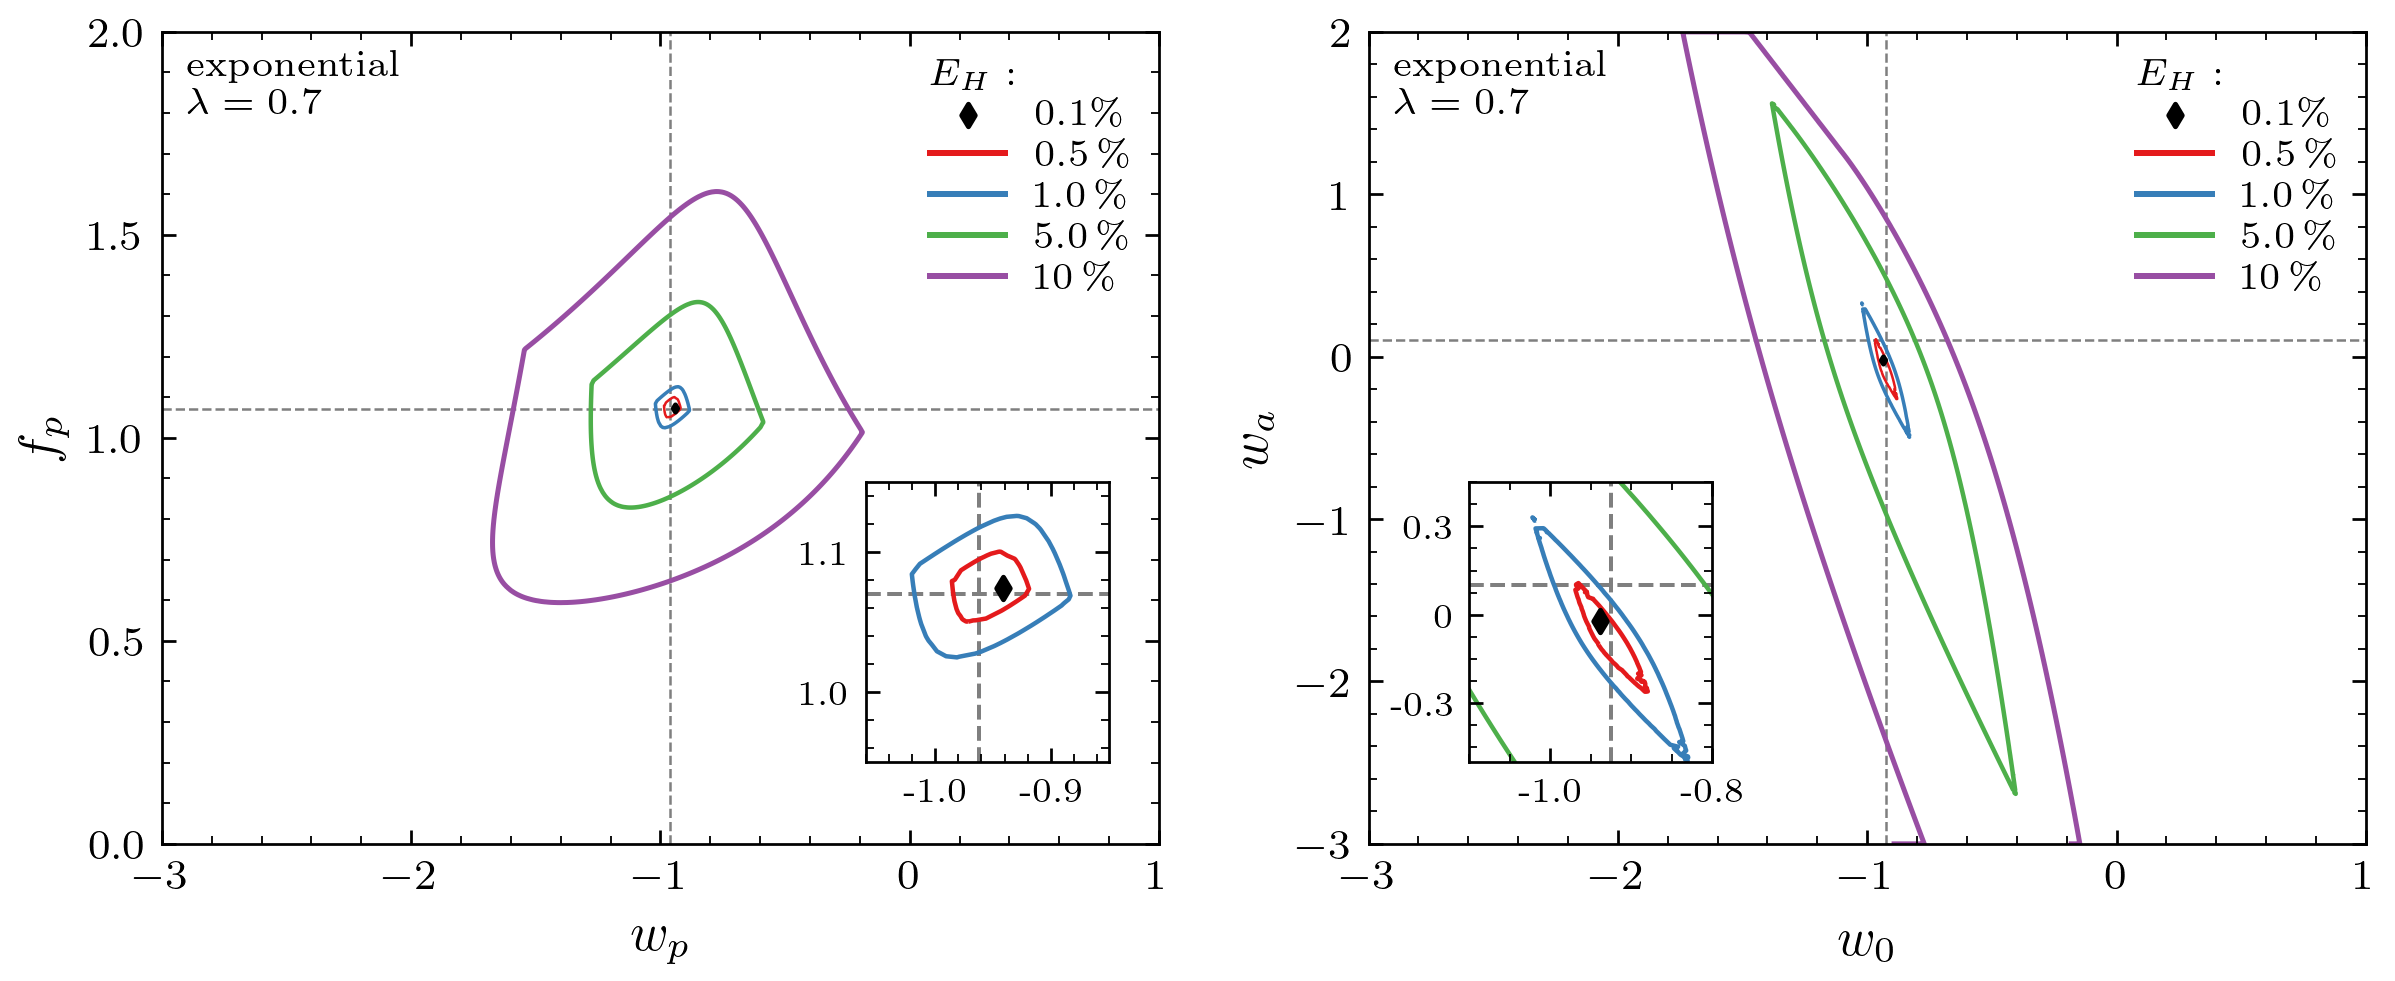

In [24]:

cs = cm.Set1.colors[:4]
fig = plt.figure(figsize=(7.9, 7.9/1.61803398875*0.6))

gs = GridSpec(20, 44, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax2= fig.add_subplot(gs[:, :20])
ax1= fig.add_subplot(gs[:, 24:])
ax4= fig.add_subplot(gs[11:18, 14:19])
ax3= fig.add_subplot(gs[11:18, 26:31])
ax1.set_xlim(-3,1)
ax1.set_ylim(-3,2)
ax2.set_xlim(-3,1)
ax2.set_ylim(0.,2)
ax3.set_xlim(-1.1,-0.8)
ax3.set_ylim(-.5,.45)
ax3.set_yticks([-0.3,0,0.3])
ax3.set_yticklabels([-0.3,0,0.3], fontsize=7)
ax3.set_xticks([-1,-0.8])
ax3.set_xticklabels([-1.0,-0.8], fontsize=7)

ax4.set_xlim(-1.06,-0.85)
ax4.set_ylim(0.95,1.15)
ax4.set_yticks([1,1.1])
ax4.set_yticklabels([1.0,1.1], fontsize=7)
ax4.set_xticks([-1,-0.9])
ax4.set_xticklabels([-1.0,-0.9], fontsize=7)


#ax1.set_xticks([-3,-2,-1,0,1])
#ax1.set_yticks([-3,-2,-1,0,1,2])
#ax2.set_xticks([-2,-1,0,1])
ax2.set_yticks([0,0.5,1,1.5,2])
ax1.set_ylabel(r"$w_a$")
ax1.set_xlabel(r"$w_0$")
ax2.set_xlabel(r"$w_p$")
ax2.set_ylabel(r"$f_p$")

ax1.tricontour(tri_cpl, E_cpl, levels=[0.005,0.01,0.05,0.1],colors=cs, linewidths=[.5,0.7,0.9,1])
ax2.tricontour(tri_piv, E_piv, levels=[0.005,0.01,0.05,0.1],colors=cs, linewidths=[.5,0.7,0.9,1])
ax3.tricontour(tri_cpl, E_cpl, levels=[0.005,0.01,0.05,0.1],colors=cs, linewidths=[.9,0.9,0.9,.9])
ax4.tricontour(tri_piv, E_piv, levels=[0.005,0.01,0.05,0.1],colors=cs, linewidths=[.9,0.9,0.9,.9])
ax1.scatter(np.NaN,np.NaN,marker='d',s=10,color='k',label='$0.1\%$')
ax2.scatter(np.NaN,np.NaN,marker='d',s=10,color='k',label='$0.1\%$')
thr_tex=[r'$0.5\,\%$',r'$1.0\,\%$',r'$5.0\,\%$','$10\,\%$']
for i in range(len(cs)):
    ax1.plot(np.NaN,np.NaN,ls='-',lw=1.2,c=cs[i],label=thr_tex[i])
    ax2.plot(np.NaN,np.NaN,ls='-',lw=1.2,c=cs[i],label=thr_tex[i])
ax1.scatter(w0wa_bf_Exp[0],w0wa_bf_Exp[1],marker='d',s=1,color='k',zorder=10)
ax3.scatter(w0wa_bf_Exp[0],w0wa_bf_Exp[1],marker='d',s=10,color='k',zorder=10)
ax2.scatter(fpwp_bf_Exp[0],fpwp_bf_Exp[1],marker='d',s=1,color='k',zorder=10)
ax4.scatter(fpwp_bf_Exp[0],fpwp_bf_Exp[1],marker='d',s=10,color='k',zorder=10)
ax1.axhline(waExp,color='tab:gray',ls='--',lw=.5,zorder=-1)
ax1.axvline(w0Exp,color='tab:gray',ls='--',lw=.5,zorder=-1)
ax3.axhline(waExp,color='tab:gray',ls='--',lw=.8,zorder=-1)
ax3.axvline(w0Exp,color='tab:gray',ls='--',lw=.8,zorder=-1)
ax2.axhline(fpivExp,color='tab:gray',ls='--',lw=.5,zorder=-1)
ax2.axvline(wpivExp,color='tab:gray',ls='--',lw=.5,zorder=-1)
ax4.axhline(fpivExp,color='tab:gray',ls='--',lw=.8,zorder=-1)
ax4.axvline(wpivExp,color='tab:gray',ls='--',lw=.8,zorder=-1)
handles, labels = ax1.get_legend_handles_labels()
order = [4, 0, 1, 2, 3]  # diamond first, then the four lines
leg1=ax1.legend([handles[i] for i in order], [labels[i] for i in order],title="$E_H:$",title_fontsize=mpl.rcParams['legend.fontsize'])
leg1._legend_box.align = "left"
leg1.get_title().set_ha('left')
handles, labels = ax2.get_legend_handles_labels()
order = [4, 0, 1, 2, 3]  # diamond first, then the four lines
leg2=ax2.legend([handles[i] for i in order], [labels[i] for i in order],title="$E_H:$",title_fontsize=mpl.rcParams['legend.fontsize'])
leg2._legend_box.align = "left"
leg2.get_title().set_ha('left')
ax1.text(-2.9,1.5, 'exponential\n'+'$\lambda=0.7$', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(-2.9,1.8, 'exponential\n'+'$\lambda=0.7$', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
plt.savefig("figs/exp_l0.7_w0wa_fpwp_Hfits.png")
plt.savefig("figs/exp_l0.7_w0wa_fpwp_Hfits.pdf")
plt.show()
plt.close()